# Document Repacking Goldilocks: TechQA (RAGBench)

Same document-repacking search methodology as
`delucion_dataset/15_document_repacking_goldilocks.ipynb`, applied to TechQA on top of
`11`, `12`, `13`, and `14`'s real TechQA winners:

- **Chunking** (`11`): recursive-character chunking, 128-token nominal target (~90 actual
  tokens/chunk), 10% overlap
- **Retriever** (`12`): hybrid (BM25 + dense), alpha=0.5 -- the untuned default
- **Query transformation** (`13`): HyDE, **three** hypothetical documents concatenated with
  the query, driving retrieval only
- **Reranker** (`14`): Cohere Rerank 4-Pro over a candidate pool of **30** (TechQA's own
  Phase 1/2 winner -- wider than DelucionQA's winning pool of 20)

Same wrinkle as DelucionQA's `15`: `14`'s TechQA winner keeps only **final_k=2** reranked
chunks, too narrow for repacking strategy to mean anything (forward/reverse/sides all
collapse to the same 2-chunk ordering). This notebook deliberately tests repacking at wider
final_k depths (reusing `14`'s own Phase 3 candidates) before asking the question that
matters: **does a wider, well-ordered context ever beat `14`'s narrow final_k=2 cut?**
DelucionQA's answer was no. TechQA's own additional wrinkle is worth watching for here too:
`14`'s TechQA analysis found Adherence actually *improves* with wider final_k (0.65 at
fk=2 rising to 0.85 at fk=12) -- a real precision/faithfulness tradeoff DelucionQA never
showed. Whether that tradeoff is enough to let a wider, repacked context win here is exactly
what Phase 3 below tests.

Same rigor throughout: fixed 20-question evaluation set reused across every config, judge
annotation retries, and the same composite score (0.35·Relevance + 0.15·Utilization +
0.15·Completeness + 0.35·Adherence) for comparability across datasets.


## Step 1: Install Dependencies

In [1]:
!pip install -q python-dotenv datasets tiktoken langchain-core langchain-text-splitters langchain-huggingface langchain-chroma langchain-openai nltk matplotlib rank-bm25 requests


[notice] A new release of pip is available: 25.2 -> 26.2
[notice] To update, run: pip install --upgrade pip


## Step 2: Imports & Setup

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests
from dotenv import load_dotenv
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from langchain_text_splitters import RecursiveCharacterTextSplitter

load_dotenv()
openrouter_token = os.environ.get("OPENROUTER_TOKEN")

import sys


def _add_ragbench_lib_to_path():
    """ragbench_lib physically lives under delucion_dataset/ -- shared, not
    duplicated, across every dataset folder in this repo."""
    here = os.getcwd()
    candidates = (
        here,
        os.path.join(here, "delucion_dataset"),
        os.path.join(os.path.dirname(here), "delucion_dataset"),
        os.path.join(here, "..", "delucion_dataset"),
    )
    for candidate in candidates:
        candidate = os.path.abspath(candidate)
        if os.path.isdir(os.path.join(candidate, "ragbench_lib")) and candidate not in sys.path:
            sys.path.insert(0, candidate)
            return
    raise RuntimeError("Could not locate the shared ragbench_lib package (expected under delucion_dataset/).")


_add_ragbench_lib_to_path()

from ragbench_lib.data_loading import load_rag_bench_data
from ragbench_lib.models import get_embedding_model, get_generation_llm, get_judge_llm
from ragbench_lib.generation_prompt import RAG_GENERATION_PROMPT
from ragbench_lib.chunking import count_tokens, get_sentences
from ragbench_lib.retrievers import HybridRetriever
from ragbench_lib.trace_eval import (
    annotate_response_for_metrics_with_retry,
    compute_context_relevance,
    compute_utilization,
    compute_completeness,
    compute_adherence,
)

print("✓ All imports successful")


/Users/saikrishna/Desktop/Codespace/IIIT_AI_ML_course/Capstone_Project/reliablerag/.venv-1/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✓ All imports successful


## Step 3: Load Dataset (fixed evaluation set)

Same fixed-sample mechanism as `11`-`14` -- `EVAL_SAMPLE_SIZE` questions chosen once, up
front, and reused for every config in every phase below.

In [3]:
DATASET_NAME = "techqa"  # RAGBench's tech-forum Q&A config
EVAL_SAMPLE_SIZE = 20

print("Loading dataset...")
docs_df = load_rag_bench_data(DATASET_NAME, num_samples=max(EVAL_SAMPLE_SIZE + 10, 30))
print(f"✓ Loaded {len(docs_df)} documents from {docs_df['row_id'].nunique()} unique questions")

eval_questions_df = docs_df.drop_duplicates(subset=["row_id"]).head(EVAL_SAMPLE_SIZE).reset_index(drop=True)
print(f"✓ Fixed evaluation set: {len(eval_questions_df)} unique questions (reused for every config below)")


Loading dataset...
✓ Loaded 150 documents from 30 unique questions
✓ Fixed evaluation set: 20 unique questions (reused for every config below)


## Step 4: Models

In [4]:
embedding_model = get_embedding_model(openrouter_token)
llm = get_generation_llm(openrouter_token)
query_llm = get_generation_llm(openrouter_token, temperature=0.7, max_tokens=256)
llama_judge = get_judge_llm(openrouter_token)
prompt = RAG_GENERATION_PROMPT

print("✓ Embedding model, generator, query-transform LLM, and judge configured")


✓ Embedding model, generator, query-transform LLM, and judge configured


## Step 5: Fixed Chunking + Retrieval + Query-Transformation + Reranking Foundation

Every layer below this notebook's own variable is frozen at TechQA's actual winning config:

- **Chunking**: recursive-character chunking, 128-token nominal target (~90 actual
  tokens/chunk), 10% overlap (`11`)
- **Retriever**: hybrid (BM25 + dense), alpha=0.5, wide candidate pool (`12`)
- **Query transformation**: HyDE, three hypothetical documents concatenated with the query,
  driving retrieval only (`13`)
- **Reranker**: Cohere Rerank 4-Pro over a candidate pool of 30 (`14`'s Phase 1/2 winner)

Repacking strategy and final_k (how many reranked chunks to keep, and in what order) are
this notebook's independent variables.

In [5]:
CHUNK_TARGET_TOKENS = 128
CHUNK_OVERLAP_FRACTION = 0.10
RETRIEVER_ALPHA = 0.5
CANDIDATE_K = 30  # 14's winning candidate pool width


def recursive_character_chunks(docs_df, target_tokens=128, overlap_fraction=0.1):
    """LangChain's standard RecursiveCharacterTextSplitter -- 11's TechQA winner.
    ~4 chars/token heuristic converts the token budget into the character-based
    splitter's units."""
    chunk_size_chars = target_tokens * 4
    overlap_chars = int(chunk_size_chars * overlap_fraction)
    splitter = RecursiveCharacterTextSplitter(chunk_size=chunk_size_chars, chunk_overlap=overlap_chars)
    documents = []
    for _, doc in docs_df.iterrows():
        for chunk_idx, chunk_text in enumerate(splitter.split_text(doc["text"])):
            if chunk_text.strip():
                documents.append(Document(
                    page_content=chunk_text,
                    metadata={
                        "chunk_id": f"{doc['doc_id']}_rc{chunk_idx}",
                        "row_id": doc["row_id"],
                        "tokens": count_tokens(chunk_text),
                    },
                ))
    return documents


def apply_hyde(query, llm, n_docs=3, concat_with_query=True):
    """Winning HyDE config from 13: 3 hypothetical docs, concatenated with the
    query, used to drive retrieval only."""
    pseudo_docs = []
    for _ in range(n_docs):
        p = f"""Write a comprehensive document that would answer this question:

'{query}'

The document should be detailed and informative, covering all aspects of the answer."""
        try:
            pseudo_docs.append(llm.invoke(p).content.strip())
        except Exception:
            pass
    if not pseudo_docs:
        return query
    combined = " ".join(pseudo_docs)
    return f"{query} {combined}" if concat_with_query else combined


class OpenRouterReranker:
    """Cross-encoder reranking via OpenRouter's dedicated /api/v1/rerank endpoint.
    Returns documents in descending relevance order, alongside their relevance scores,
    so repacking strategies below can reorder that ranked list on their own terms."""

    def __init__(self, model_name, api_key):
        self.model_name = model_name
        self.api_key = api_key
        self.endpoint = "https://openrouter.ai/api/v1/rerank"

    def rerank(self, query, documents, top_k):
        if not documents:
            return documents
        doc_texts = [d.page_content for d in documents]
        headers = {"Authorization": f"Bearer {self.api_key}", "Content-Type": "application/json"}
        payload = {"model": self.model_name, "query": query, "documents": doc_texts, "top_n": top_k}
        try:
            response = requests.post(self.endpoint, headers=headers, json=payload, timeout=30)
            response.raise_for_status()
            result = response.json()
            if "results" in result:
                ranked = sorted(result["results"], key=lambda r: r.get("relevance_score", 0), reverse=True)
                indices = [r["index"] for r in ranked[:top_k]]
                return [documents[i] for i in indices]
            return documents[:top_k]
        except Exception as e:
            print(f"    [DEBUG] rerank error ({self.model_name}): {str(e)[:60]}")
            return documents[:top_k]


print("Building fixed chunking foundation (recursive_char, 128t nominal, 10% overlap)...")
documents = recursive_character_chunks(docs_df, target_tokens=CHUNK_TARGET_TOKENS, overlap_fraction=CHUNK_OVERLAP_FRACTION)
print(f"✓ Built {len(documents)} chunks, avg {np.mean([d.metadata['tokens'] for d in documents]):.0f} tokens/chunk")

print(f"Building wide hybrid retriever foundation (alpha=0.5, k={CANDIDATE_K})...")
wide_retriever = HybridRetriever(documents, embedding_model, k=CANDIDATE_K, alpha=RETRIEVER_ALPHA,
                                  dataset_name=DATASET_NAME, config_name="repack_foundation")
print("✓ Wide hybrid retriever ready")

reranker = OpenRouterReranker("cohere/rerank-4-pro", openrouter_token)
print("✓ Cohere 4-Pro reranker ready (14's Phase 1/2 winning model)")


Building fixed chunking foundation (recursive_char, 128t nominal, 10% overlap)...
✓ Built 1649 chunks, avg 90 tokens/chunk
Building wide hybrid retriever foundation (alpha=0.5, k=30)...
✓ Wide hybrid retriever ready
✓ Cohere 4-Pro reranker ready (14's Phase 1/2 winning model)


## Step 6: Repacking Strategies

Straight from the paper's §3.6: `forward` keeps the reranker's own descending-relevance
order (the implicit default every prior notebook used without naming it); `reverse` flips
to ascending relevance, putting the *most* relevant chunk immediately before the question;
`sides` splits the ranked list, placing the top-ranked chunks at both the head and tail of
the context with lower-ranked chunks in the middle -- the arrangement Liu et al. (2024a)
found LLMs attend to best.

In [6]:
def repack_forward(reranked_docs):
    """Descending relevance (reranker's own order) -- most relevant first."""
    return list(reranked_docs)


def repack_reverse(reranked_docs):
    """Ascending relevance -- most relevant last, immediately before the question."""
    return list(reversed(reranked_docs))


def repack_sides(reranked_docs):
    """Most relevant at head and tail, least relevant in the middle."""
    n = len(reranked_docs)
    head, tail = [], []
    for i, doc in enumerate(reranked_docs):
        if i % 2 == 0:
            head.append(doc)
        else:
            tail.insert(0, doc)
    return head + tail


REPACKING_STRATEGIES = {
    "forward": repack_forward,
    "reverse": repack_reverse,
    "sides": repack_sides,
}

print("✓ Repacking strategies ready (forward, reverse, sides)")


✓ Repacking strategies ready (forward, reverse, sides)


## Step 7: Evaluation Runner

Every config runs the fixed 20-question set through: HyDE-transform the query -> retrieve
`CANDIDATE_K` hybrid-ranked candidates -> Cohere 4-Pro rerank against the original question,
keeping `final_k` -> apply the repacking strategy to reorder those `final_k` chunks ->
generate from the original question -> retry judge annotation up to 3x -> compute TRACe
metrics + the same composite score `11`-`14` used.

In [7]:
def evaluate_repacking_config(config_name, repack_fn, final_k, eval_questions_df, max_annotate_attempts=3):
    def format_docs(docs):
        return "\n\n".join(doc.page_content for doc in docs)

    rag_chain = prompt | llm | StrOutputParser()

    per_sample = []
    n_failed = 0
    for _, row in eval_questions_df.iterrows():
        original_question = row["question"]
        try:
            retrieval_query = apply_hyde(original_question, query_llm, n_docs=3, concat_with_query=True)
            candidates = wide_retriever.retrieve(retrieval_query)[:CANDIDATE_K]
            reranked_docs = reranker.rerank(original_question, candidates, top_k=final_k)
            repacked_docs = repack_fn(reranked_docs)
            retrieved_texts = [d.page_content for d in repacked_docs]

            response_text = rag_chain.invoke({"context": format_docs(repacked_docs), "question": original_question})

            annotation = annotate_response_for_metrics_with_retry(
                llama_judge, retrieved_texts, original_question, response_text, max_attempts=max_annotate_attempts
            )
            if annotation["success"]:
                per_sample.append({
                    "context_relevance": compute_context_relevance(retrieved_texts, annotation),
                    "utilization": compute_utilization(retrieved_texts, annotation),
                    "completeness": compute_completeness(annotation),
                    "adherence": compute_adherence(annotation),
                })
            else:
                n_failed += 1
        except Exception:
            n_failed += 1

    result = {
        "config": config_name,
        "final_k": final_k,
        "n_eval": len(per_sample),
        "n_failed": n_failed,
        "context_relevance": np.mean([r["context_relevance"] for r in per_sample]) if per_sample else None,
        "utilization": np.mean([r["utilization"] for r in per_sample]) if per_sample else None,
        "completeness": np.mean([r["completeness"] for r in per_sample]) if per_sample else None,
        "adherence": np.mean([r["adherence"] for r in per_sample]) if per_sample else None,
    }
    if per_sample:
        result["composite"] = (
            0.35 * result["context_relevance"]
            + 0.15 * result["utilization"]
            + 0.15 * result["completeness"]
            + 0.35 * result["adherence"]
        )
    else:
        result["composite"] = None
    return result


print("✓ evaluate_repacking_config defined")


✓ evaluate_repacking_config defined


## Step 8: Phase 1 -- Repacking Strategy Comparison (final_k=6)

final_k=6 is one of `14`'s own Phase 3 candidates (composite 0.483 there, using the
reranker's implicit forward order) -- wide enough for forward/reverse/sides to actually
differ, unlike `14`'s winning final_k=2. Isolates **repacking strategy**, with context
width fixed.

In [8]:
FINAL_K_PHASE1 = 6

print("=" * 100)
print(f"PHASE 1: REPACKING STRATEGY COMPARISON (final_k={FINAL_K_PHASE1}), {EVAL_SAMPLE_SIZE} fixed questions")
print("=" * 100)

phase1_results = []
for name, repack_fn in REPACKING_STRATEGIES.items():
    print(f"\n--- {name} ---")
    result = evaluate_repacking_config(f"p1_{name}", repack_fn, FINAL_K_PHASE1, eval_questions_df)
    phase1_results.append(result)
    if result["composite"] is not None:
        print(f"  CR={result['context_relevance']:.4f} Util={result['utilization']:.4f} "
              f"Comp={result['completeness']:.4f} Adh={result['adherence']:.4f} "
              f"Composite={result['composite']:.4f}  (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")
    else:
        print(f"  ✗ No successful evaluations (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")

phase1_df = pd.DataFrame(phase1_results).sort_values("composite", ascending=False, na_position="last")
print("\n" + "=" * 100)
print("PHASE 1 RESULTS (ranked by composite score)")
print("=" * 100)
display(phase1_df)


PHASE 1: REPACKING STRATEGY COMPARISON (final_k=6), 20 fixed questions

--- forward ---
  CR=0.3321 Util=0.2394 Comp=0.5925 Adh=0.6500 Composite=0.4685  (failed 0/20)

--- reverse ---
  CR=0.2833 Util=0.1402 Comp=0.4157 Adh=0.6500 Composite=0.4101  (failed 0/20)

--- sides ---
  CR=0.3675 Util=0.2031 Comp=0.4702 Adh=0.6500 Composite=0.4571  (failed 0/20)

PHASE 1 RESULTS (ranked by composite score)


,config,final_k,n_eval,n_failed,context_relevance,utilization,completeness,adherence,composite
0,p1_forward,6,20,0,0.332080,0.239435,0.592545,0.65,0.468525
2,p1_sides,6,20,0,0.367475,0.203105,0.470190,0.65,0.457110
1,p1_reverse,6,20,0,0.283350,0.140230,0.415745,0.65,0.410069


## Step 9: Phase 2 -- Does Repacking's Value Scale With Context Width?

Takes Phase 1's winning strategy and sweeps final_k, holding strategy fixed -- tests the
paper's own "lost in the middle" motivation for repacking directly: does ordering matter
more as more chunks get crammed into context, or does it stay flat regardless of width?

In [9]:
phase1_winner = phase1_df.iloc[0]["config"].replace("p1_", "")
repack_fn = REPACKING_STRATEGIES[phase1_winner]
print(f"Phase 1 winner: {phase1_winner} -- sweeping final_k next\n")

final_k_values = [4, 6, 8, 12]

print("=" * 100)
print(f"PHASE 2: FINAL_K SWEEP for '{phase1_winner}' repacking, {EVAL_SAMPLE_SIZE} fixed questions")
print("=" * 100)

phase2_results = []
for final_k in final_k_values:
    print(f"\n--- {phase1_winner} @ final_k={final_k} ---")
    result = evaluate_repacking_config(f"p2_{phase1_winner}_fk{final_k}", repack_fn, final_k, eval_questions_df)
    phase2_results.append(result)
    if result["composite"] is not None:
        print(f"  CR={result['context_relevance']:.4f} Adh={result['adherence']:.4f} "
              f"Composite={result['composite']:.4f}  (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")
    else:
        print(f"  ✗ No successful evaluations (failed {result['n_failed']}/{EVAL_SAMPLE_SIZE})")

phase2_df = pd.DataFrame(phase2_results).sort_values("composite", ascending=False, na_position="last")
print("\n" + "=" * 100)
print("PHASE 2 RESULTS (ranked by composite score)")
print("=" * 100)
display(phase2_df)


Phase 1 winner: forward -- sweeping final_k next

PHASE 2: FINAL_K SWEEP for 'forward' repacking, 20 fixed questions

--- forward @ final_k=4 ---
  CR=0.4652 Adh=0.7500 Composite=0.5388  (failed 0/20)

--- forward @ final_k=6 ---
  CR=0.3508 Adh=0.8000 Composite=0.5224  (failed 0/20)

--- forward @ final_k=8 ---
  CR=0.2062 Adh=0.6500 Composite=0.4128  (failed 0/20)

--- forward @ final_k=12 ---
  CR=0.1768 Adh=0.7500 Composite=0.3983  (failed 0/20)

PHASE 2 RESULTS (ranked by composite score)


,config,final_k,n_eval,n_failed,context_relevance,utilization,completeness,adherence,composite
0,p2_forward_fk4,4,20,0,0.465230,0.247635,0.509115,0.75,0.538843
1,p2_forward_fk6,6,20,0,0.350850,0.208015,0.589405,0.80,0.522410
2,p2_forward_fk8,8,20,0,0.206155,0.126250,0.627730,0.65,0.412751
3,p2_forward_fk12,12,20,0,0.176785,0.067585,0.425550,0.75,0.398345


## Step 10: Phase 3 -- Wide-and-Repacked vs. `14`'s Narrow Winner

The question this whole notebook exists to answer: does *any* final_k + repacking
combination beat `14`'s raw final_k=2, no-repacking-needed winner (composite 0.709)? Runs
Phase 2's best config directly against a fresh final_k=2 measurement (using this notebook's
own pipeline, for an apples-to-apples comparison rather than citing `14`'s number
directly).

In [10]:
phase2_winner_config = phase2_df.iloc[0]["config"]
phase2_winner_final_k = int(phase2_df.iloc[0]["final_k"])
print(f"Phase 2 winner: {phase2_winner_config} (final_k={phase2_winner_final_k}) -- "
      f"comparing against a fresh final_k=2 baseline\n")

print("=" * 100)
print(f"PHASE 3: WIDE+REPACKED vs. NARROW (final_k=2), {EVAL_SAMPLE_SIZE} fixed questions")
print("=" * 100)

phase3_results = []

print(f"\n--- {phase1_winner} @ final_k={phase2_winner_final_k} (Phase 2 winner) ---")
result = evaluate_repacking_config(f"p3_{phase1_winner}_fk{phase2_winner_final_k}", repack_fn, phase2_winner_final_k, eval_questions_df)
phase3_results.append(result)
if result["composite"] is not None:
    print(f"  CR={result['context_relevance']:.4f} Adh={result['adherence']:.4f} Composite={result['composite']:.4f}")

print(f"\n--- final_k=2, no repacking needed (forward order, single ordering) ---")
result = evaluate_repacking_config("p3_narrow_fk2", repack_forward, 2, eval_questions_df)
phase3_results.append(result)
if result["composite"] is not None:
    print(f"  CR={result['context_relevance']:.4f} Adh={result['adherence']:.4f} Composite={result['composite']:.4f}")

phase3_df = pd.DataFrame(phase3_results).sort_values("composite", ascending=False, na_position="last")
print("\n" + "=" * 100)
print("PHASE 3 RESULTS (ranked by composite score)")
print("=" * 100)
display(phase3_df)


Phase 2 winner: p2_forward_fk4 (final_k=4) -- comparing against a fresh final_k=2 baseline

PHASE 3: WIDE+REPACKED vs. NARROW (final_k=2), 20 fixed questions

--- forward @ final_k=4 (Phase 2 winner) ---
  CR=0.4558 Adh=0.7500 Composite=0.5445

--- final_k=2, no repacking needed (forward order, single ordering) ---
  CR=0.5938 Adh=0.7000 Composite=0.5704

PHASE 3 RESULTS (ranked by composite score)


,config,final_k,n_eval,n_failed,context_relevance,utilization,completeness,adherence,composite
1,p3_narrow_fk2,2,20,0,0.593765,0.26316,0.520830,0.70,0.570416
0,p3_forward_fk4,4,20,0,0.455800,0.24246,0.574055,0.75,0.544507


## Step 11: Visualize the Search

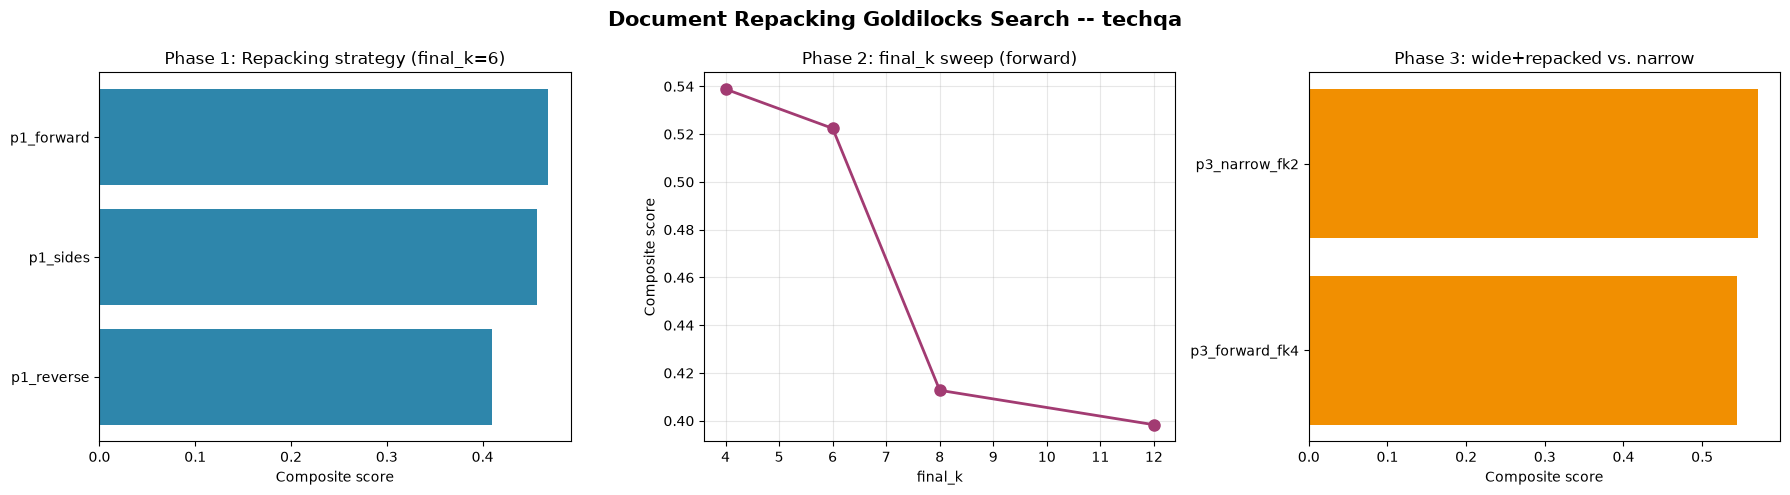

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f"Document Repacking Goldilocks Search -- {DATASET_NAME}", fontsize=15, fontweight="bold")

p1_plot = phase1_df.dropna(subset=["composite"]).sort_values("composite")
axes[0].barh(p1_plot["config"], p1_plot["composite"], color="#2E86AB")
axes[0].set_xlabel("Composite score")
axes[0].set_title(f"Phase 1: Repacking strategy (final_k={FINAL_K_PHASE1})")

p2_plot = phase2_df.dropna(subset=["composite"]).sort_values("final_k")
axes[1].plot(p2_plot["final_k"], p2_plot["composite"], "o-", color="#A23B72", linewidth=2, markersize=8)
axes[1].set_xlabel("final_k")
axes[1].set_ylabel("Composite score")
axes[1].set_title(f"Phase 2: final_k sweep ({phase1_winner})")
axes[1].grid(True, alpha=0.3)

p3_plot = phase3_df.dropna(subset=["composite"]).sort_values("composite")
axes[2].barh(p3_plot["config"], p3_plot["composite"], color="#F18F01")
axes[2].set_xlabel("Composite score")
axes[2].set_title("Phase 3: wide+repacked vs. narrow")

plt.tight_layout()
plt.show()


## Step 12: Final Recommendation

In [12]:
all_results_df = pd.concat([phase1_df, phase2_df, phase3_df], ignore_index=True)
all_results_df = all_results_df.dropna(subset=["composite"]).sort_values("composite", ascending=False)

print("=" * 100)
print("ALL CONFIGS ACROSS ALL THREE PHASES, RANKED BY COMPOSITE SCORE")
print("=" * 100)
display(all_results_df[[
    "config", "final_k", "n_eval", "n_failed",
    "context_relevance", "utilization", "completeness", "adherence", "composite",
]])

best = all_results_df.iloc[0]
narrow_row = phase3_df[phase3_df["config"] == "p3_narrow_fk2"].iloc[0]

print("\n" + "=" * 100)
print(f"🏆 GOLDILOCKS REPACKING CONFIG: {best['config']}")
print("=" * 100)
print(f"  final_k:            {best['final_k']:.0f}")
print(f"  Context Relevance:  {best['context_relevance']:.4f}")
print(f"  Utilization:        {best['utilization']:.4f}")
print(f"  Completeness:       {best['completeness']:.4f}")
print(f"  Adherence:          {best['adherence']:.4f}")
print(f"  Composite:          {best['composite']:.4f}")
print(f"  Eval sample:        {best['n_eval']}/{EVAL_SAMPLE_SIZE} succeeded (failed: {best['n_failed']})")
if narrow_row["composite"] is not None and best["config"] != "p3_narrow_fk2":
    delta = best["composite"] - narrow_row["composite"]
    print(f"  vs. narrow final_k=2 (no repacking needed): {delta:+.4f} composite "
          f"({'wide+repacked wins' if delta > 0 else 'narrow final_k=2 still wins'})")
print("=" * 100)


ALL CONFIGS ACROSS ALL THREE PHASES, RANKED BY COMPOSITE SCORE


,config,final_k,n_eval,n_failed,context_relevance,utilization,completeness,adherence,composite
7,p3_narrow_fk2,2,20,0,0.593765,0.263160,0.520830,0.70,0.570416
8,p3_forward_fk4,4,20,0,0.455800,0.242460,0.574055,0.75,0.544507
3,p2_forward_fk4,4,20,0,0.465230,0.247635,0.509115,0.75,0.538843
4,p2_forward_fk6,6,20,0,0.350850,0.208015,0.589405,0.80,0.522410
0,p1_forward,6,20,0,0.332080,0.239435,0.592545,0.65,0.468525
1,p1_sides,6,20,0,0.367475,0.203105,0.470190,0.65,0.457110
5,p2_forward_fk8,8,20,0,0.206155,0.126250,0.627730,0.65,0.412751
2,p1_reverse,6,20,0,0.283350,0.140230,0.415745,0.65,0.410069
6,p2_forward_fk12,12,20,0,0.176785,0.067585,0.425550,0.75,0.398345



🏆 GOLDILOCKS REPACKING CONFIG: p3_narrow_fk2
  final_k:            2
  Context Relevance:  0.5938
  Utilization:        0.2632
  Completeness:       0.5208
  Adherence:          0.7000
  Composite:          0.5704
  Eval sample:        20/20 succeeded (failed: 0)


### Caveats -- do not treat these exact numbers as final

- **Still a single run on one fixed 20-question sample.** Retrying failed annotations and
  reusing the same question set across every config removes some noise, but this is one
  dataset draw.
- **Chunking, retriever, query transformation, and reranker held constant** at `11`-`14`'s
  winning configs. Whether a different upstream pipeline changes which repacking strategy
  wins (or whether repacking matters at all) is not explored here.
- **`query_llm` runs at temperature 0.7** for the HyDE retrieval string feeding every
  config's candidate pool -- a repeat run could shuffle close results even on the same
  fixed question set.
- **The `sides` implementation here is one reasonable interpretation** (alternating
  head/tail placement by rank) of the paper's description; the paper doesn't specify an
  exact algorithm, so a different implementation could rank differently.
- **The OpenRouter rerank endpoint is a third-party dependency** with its own latency,
  cost, and availability characteristics not modeled by the composite score.
- **Composite score weighting (0.35/0.15/0.15/0.35) is a judgment call**, kept identical to
  `11`-`14` for comparability. The raw per-metric columns are in every results table if you
  want to re-rank by a different weighting or a single metric.
